In [2]:
import sys
!{sys.executable} -m pip install tensorflow matplotlib seaborn pandas

  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.0-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.12.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached ml_dtypes-0.5.3-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optre

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.66.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 6.33.0 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.0 which is incompatible.


In [3]:
import os
import glob
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
print("imported all")

imported all


In [20]:
# --- Load Parquet Files ---
def load_parquet_files(data_dir, files_to_load=8):
    parquet_files = sorted(glob.glob(os.path.join(data_dir, "*.parquet")))
    assert len(parquet_files) >= files_to_load, "Not enough .parquet files found."
    data_chunks = []
    for file in parquet_files[:files_to_load]:
        print(f"Loading: {os.path.basename(file)}")
        pf = pd.read_parquet(file, engine="pyarrow")
        for col in pf.select_dtypes('number').columns:
            if 'int' in str(pf[col].dtype):
                pf[col] = pd.to_numeric(pf[col], downcast='integer')
            elif 'float' in str(pf[col].dtype):
                pf[col] = pd.to_numeric(pf[col], downcast='float')
        for col in pf.select_dtypes('object').columns:
            if pf[col].nunique() < 0.5 * len(pf):
                pf[col] = pf[col].astype('category')
        data_chunks.append(pf)
        gc.collect()
    df = pd.concat(data_chunks, ignore_index=True)
    return df

DATA_DIR = r"C:\Users\Harshith\Downloads\archive"

print("\n# Loading data efficiently from Parquet files...")
df = load_parquet_files(DATA_DIR, files_to_load=8)
print(f"Loaded dataframe shape: {df.shape}")



# Loading data efficiently from Parquet files...
Loading: Benign-Monday-no-metadata.parquet
Loading: Botnet-Friday-no-metadata.parquet
Loading: Bruteforce-Tuesday-no-metadata.parquet
Loading: DDoS-Friday-no-metadata.parquet
Loading: DoS-Wednesday-no-metadata.parquet
Loading: Infiltration-Thursday-no-metadata.parquet
Loading: Portscan-Friday-no-metadata.parquet
Loading: WebAttacks-Thursday-no-metadata.parquet
Loaded dataframe shape: (2313810, 78)


In [22]:
# --- Data Cleaning ---
drop_cols = [
    'Flow ID', 'Src IP', 'Dst IP', 'Dst Port', 'Timestamp', 'Source IP',
    'Destination IP', 'Fwd Header Length.1', 'Start time', 'Last time',
    'Attack Name', 'Attack Reference', '.', 'Attack category', 'Attack subcategory',
    'Source Port', 'Destination Port'
]

df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors='ignore')

if 'Label' in df.columns:
    df['Label'] = df['Label'].astype(str).str.strip().str.upper()
else:
    df['Label'] = 'BENIGN'  # Default to benign if no Label column

print("\nLabel distribution after cleaning:")
print(df['Label'].value_counts())



Label distribution after cleaning:
Label
BENIGN                        1977318
DOS HULK                       172846
DDOS                           128014
DOS GOLDENEYE                   10286
FTP-PATATOR                      5931
DOS SLOWLORIS                    5385
DOS SLOWHTTPTEST                 5228
SSH-PATATOR                      3219
PORTSCAN                         1956
WEB ATTACK � BRUTE FORCE         1470
BOT                              1437
WEB ATTACK � XSS                  652
INFILTRATION                       36
WEB ATTACK � SQL INJECTION         21
HEARTBLEED                         11
Name: count, dtype: int64


In [26]:
# --- Split Data for Supervised and Unsupervised ---
benign_data = df[df['Label'] == 'BENIGN'].copy()
attack_data = df[df['Label'] != 'BENIGN'].copy()

supervised_df = pd.concat([benign_data.sample(frac=0.3, random_state=42), attack_data], axis=0)
unsupervised_df = benign_data.drop(supervised_df.index, errors='ignore')

y_supervised = supervised_df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1).values
X_supervised = supervised_df.drop(columns=['Label'])
X_unsupervised = unsupervised_df.drop(columns=['Label'])

# Convert object columns to numeric
for df_part in [X_supervised, X_unsupervised]:
    for col in df_part.columns:
        if df_part[col].dtype == 'object':
            df_part[col] = pd.to_numeric(df_part[col], errors='coerce').fillna(0)

# Remove constant columns
const_cols = X_supervised.columns[X_supervised.nunique() <= 1]
X_supervised.drop(columns=const_cols, inplace=True)
X_unsupervised.drop(columns=const_cols, inplace=True)


In [28]:
X_supervised.fillna(0, inplace=True)
X_unsupervised.fillna(0, inplace=True)


In [30]:
# --- Feature Scaling ---
scaler = StandardScaler()
X_supervised_scaled = scaler.fit_transform(X_supervised)
X_unsupervised_scaled = scaler.transform(X_unsupervised.reindex(columns=X_supervised.columns, fill_value=0))

# --- Reshape for LSTM Autoencoder (1 timestep) ---
timesteps = 1
input_dim = X_supervised_scaled.shape[1]

X_supervised_lstm = X_supervised_scaled.reshape(-1, timesteps, input_dim)
X_unsupervised_lstm = X_unsupervised_scaled.reshape(-1, timesteps, input_dim)

print(f"Shapes: Supervised {X_supervised_lstm.shape}, Unsupervised {X_unsupervised_lstm.shape}")


Shapes: Supervised (929687, 1, 69), Unsupervised (1384123, 1, 69)


In [34]:
# --- Define Hybrid Autoencoder Model ---
def build_hybrid_autoencoder(timesteps, input_dim, learning_rate=0.0001):
    inputs = Input(shape=(timesteps, input_dim))
    
    # LSTM encoder
    lstm_enc = LSTM(64, activation='relu', return_sequences=True)(inputs)
    lstm_enc = Dropout(0.2)(lstm_enc)
    lstm_enc = LSTM(32, activation='relu', return_sequences=False)(lstm_enc)
    lstm_enc = Dropout(0.2)(lstm_enc)
    
    # FNN encoder
    fnn_input = Flatten()(inputs)
    fnn_enc = Dense(64, activation='relu')(fnn_input)
    fnn_enc = Dropout(0.2)(fnn_enc)
    fnn_enc = Dense(32, activation='relu')(fnn_enc)
    
    # Concatenate encoded features
    concat = Concatenate()([lstm_enc, fnn_enc])
    
    # Decoder
    decoder = Dense(64, activation='relu')(concat)
    decoder = Dropout(0.2)(decoder)
    decoder_output = Dense(timesteps * input_dim, activation='linear')(decoder)
    decoder_reshaped = tf.keras.layers.Reshape((timesteps, input_dim))(decoder_output)
    
    model = Model(inputs, decoder_reshaped)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

In [36]:
# --- Train Autoencoder ---
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.0001

autoencoder = build_hybrid_autoencoder(timesteps, input_dim, LEARNING_RATE)
history = autoencoder.fit(
    X_unsupervised_lstm, X_unsupervised_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 11.3116 - val_loss: 0.7118
Epoch 2/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 10.5098 - val_loss: 0.6002
Epoch 3/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 8.5591 - val_loss: 0.5185
Epoch 4/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 7.0078 - val_loss: 0.4780
Epoch 5/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 7.3005 - val_loss: 0.4432
Epoch 6/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 6.3096 - val_loss: 0.4290
Epoch 7/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 6.2344 - val_loss: 0.4150
Epoch 8/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 6.0035 - val_loss: 0.4072
Epoch 9/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 5.7102 - val_loss: 0.3992
Epoch 10/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 6.1457 - val_loss: 0.3911
Epoch 11/20
4326/4326 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 4.4470 - val_loss: 0.3950
Epoch 12/20
4326/

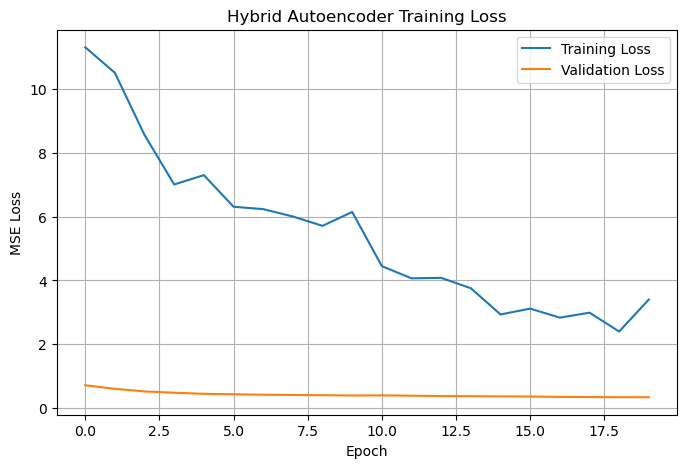

In [38]:

# --- Plot Loss ---
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Hybrid Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

29053/29053 ━━━━━━━━━━━━━━━━━━━━ 26s 872us/step


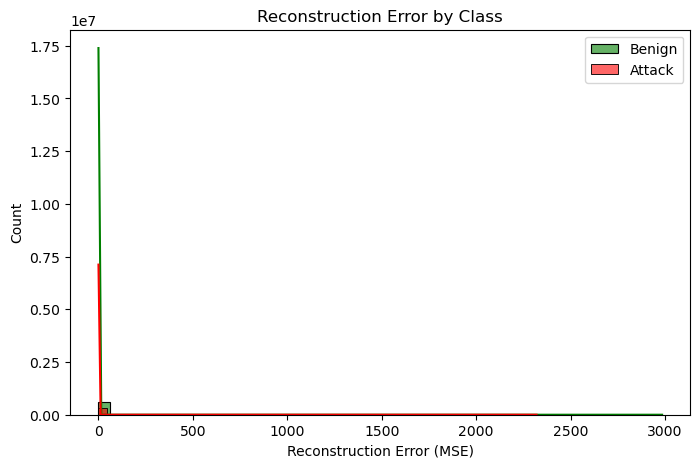

In [40]:
# --- Calculate Reconstruction Errors on Supervised Data ---
X_supervised_reconstructed = autoencoder.predict(X_supervised_lstm)
supervised_errors = np.mean(np.square(X_supervised_lstm - X_supervised_reconstructed), axis=(1,2))

# --- Plot Reconstruction Error Distribution ---
plt.figure(figsize=(8,5))
sns.histplot(supervised_errors[y_supervised == 0], color='green', bins=50, alpha=0.6, label='Benign', kde=True)
sns.histplot(supervised_errors[y_supervised == 1], color='red', bins=50, alpha=0.6, label='Attack', kde=True)
plt.title('Reconstruction Error by Class')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.show()


In [42]:
# Remove NaNs from supervised_errors and corresponding labels
mask = ~np.isnan(supervised_errors)
cleaned_errors = supervised_errors[mask]
cleaned_labels = y_supervised[mask]

auc = roc_auc_score(cleaned_labels, cleaned_errors)
print(f"ROC-AUC Score based on reconstruction error: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(cleaned_labels, cleaned_errors)


ROC-AUC Score based on reconstruction error: 0.9010


In [44]:
print(np.isnan(X_supervised_scaled).sum())  # Should be 0
print(np.isnan(X_unsupervised_scaled).sum()) # Should be 0


0
0


ROC-AUC Score based on reconstruction error: 0.9010


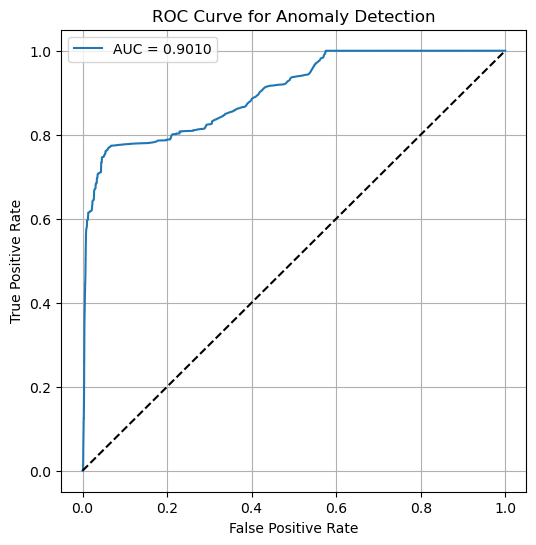

In [46]:
# --- ROC-AUC Evaluation ---
auc = roc_auc_score(y_supervised, supervised_errors)
print(f"ROC-AUC Score based on reconstruction error: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_supervised, supervised_errors)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.grid()
plt.show()

Optimal Threshold for anomaly detection: 0.129400


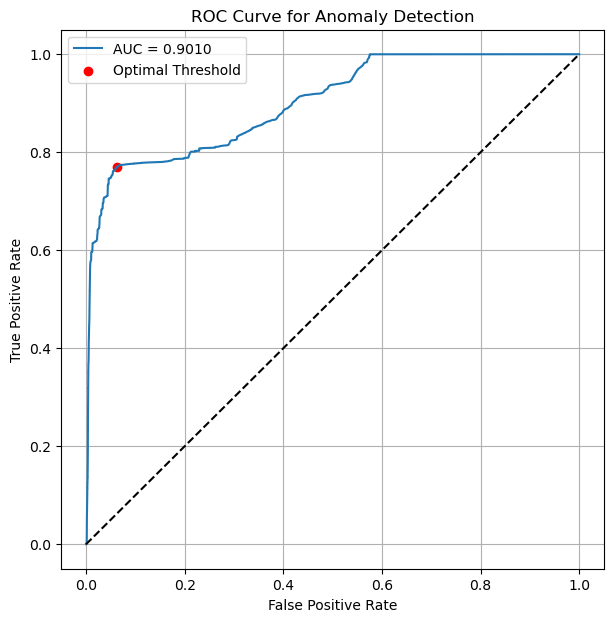

Average Precision Score: 0.8655


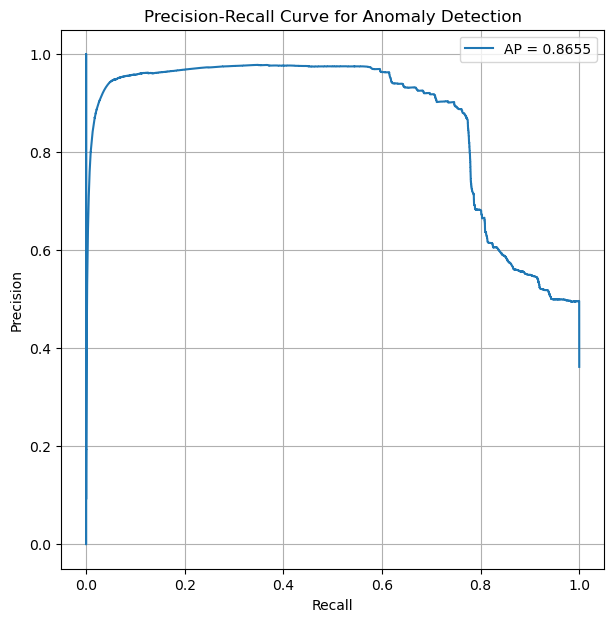

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Using existing fpr, tpr, thresholds from ROC curve
# Find optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold for anomaly detection: {optimal_threshold:.6f}")

# Plot ROC curve with threshold
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label='Optimal Threshold')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.grid(True)
plt.legend()
plt.show()

# Calculate Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(cleaned_labels, cleaned_errors)
ap_score = average_precision_score(cleaned_labels, cleaned_errors)
print(f'Average Precision Score: {ap_score:.4f}')

# Plot Precision-Recall Curve
plt.figure(figsize=(7,7))
plt.plot(recall, precision, label=f'AP = {ap_score:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()


In [52]:
!pip install cvss


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from cvss import CVSS3
import pandas as pd
print("import completed")

# 1. Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_supervised_scaled, y_supervised)

print("done with train classifier")
# 2. Predict attack labels on supervised data
y_pred = clf.predict(X_supervised_scaled)

print("Attack Classification Report:")
print(classification_report(y_supervised, y_pred, target_names=['Benign', 'Attack']))
print(f"Classification Accuracy: {accuracy_score(y_supervised, y_pred):.4f}")

import completed
done with train classifier
Attack Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    593195
      Attack       1.00      1.00      1.00    336492

    accuracy                           1.00    929687
   macro avg       1.00      1.00      1.00    929687
weighted avg       1.00      1.00      1.00    929687

Classification Accuracy: 0.9995


In [55]:
import numpy as np
import pandas as pd

# --- CVSS Lookup Table (example, fill in your real scores/classes) ---
cvss_lookup = {
    'DOS_HULK': 7.5,
    'DDOS': 8.0,
    'FTP-PATATOR': 6.0,
    'SSH-PATATOR': 6.5,
    'PORTSCAN': 5.0,
    'BENIGN': 0.0,
}

# 1 Predict with Random Forest for known types 
rf_pred_labels = clf.predict(X_supervised_scaled)

# 2: Calculate autoencoder reconstruction errors 
X_supervised_lstm = X_supervised_scaled.reshape(-1, 1, X_supervised_scaled.shape[1])
X_supervised_recon = autoencoder.predict(X_supervised_lstm)
recon_errors = np.mean(np.square(X_supervised_lstm - X_supervised_recon), axis=(1,2))

# 3: Hybrid Decision Logic
threshold = 0.076033  
final_labels = []
for rf_label, err in zip(rf_pred_labels, recon_errors):
    if err <= threshold:
        final_labels.append(rf_label)    
    else:
        final_labels.append('Unknown')   # Unknown anomaly (dynamic detection)

# 4: Assign CVSS Scores 
cvss_scores = []
for label in final_labels:
    cvss_scores.append(cvss_lookup.get(label, 'Dynamic/Unknown'))

hybrid_df = pd.DataFrame({
    'RF_Label': rf_pred_labels,
    'Reconstruction_Error': recon_errors,
    'Hybrid_Label': final_labels,
    'CVSS_Score': cvss_scores
})

print(hybrid_df['Hybrid_Label'].value_counts())
print(hybrid_df.groupby('Hybrid_Label')['CVSS_Score'].value_counts())

# --- Optional: For new or unsupervised data ---
X_unsup_lstm = X_unsupervised_scaled.reshape(-1, 1, X_unsupervised_scaled.shape[1])
X_unsup_recon = autoencoder.predict(X_unsup_lstm)
unsup_errors = np.mean(np.square(X_unsup_lstm - X_unsup_recon), axis=(1,2))
unsup_labels = ['Unknown' if e > threshold else 'Benign' for e in unsup_errors]
unsup_cvss = [cvss_lookup.get(l, 'Dynamic/Unknown') for l in unsup_labels]
unsup_df = pd.DataFrame({'Unsupervised_Label': unsup_labels, 'Error': unsup_errors, 'CVSS_Score': unsup_cvss})

# --- Save or further process results ---
hybrid_df.to_csv('hybrid_supervised_results.csv', index=False)
unsup_df.to_csv('hybrid_unsupervised_results.csv', index=False)


29053/29053 ━━━━━━━━━━━━━━━━━━━━ 96s 3ms/step
Hybrid_Label
0          532634
Unknown    322524
1           74529
Name: count, dtype: int64
Hybrid_Label  CVSS_Score     
0             Dynamic/Unknown    532634
1             Dynamic/Unknown     74529
Unknown       Dynamic/Unknown    322524
Name: count, dtype: int64
43254/43254 ━━━━━━━━━━━━━━━━━━━━ 127s 3ms/step


In [169]:
from cvss import CVSS3
from decimal import Decimal

manual_reference = {
    "DDOS": 9.8,
    "PORTSCAN": 3.2,
    "BOT": 9.9,
    "HEARTBLEED": 7.5,
    "BENIGN": 0.0,
    "UNKNOWN": 5.0
}

vector_reference = {
    "DDOS": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:H",
    "PORTSCAN": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:L/I:N/A:N",
    "BOT": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:C/C:H/I:H/A:H",
    "HEARTBLEED": "CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N",
    "BENIGN": "CVSS:3.1/AV:L/AC:H/PR:H/UI:R/S:U/C:N/I:N/A:N",
    "UNKNOWN": "CVSS:3.1/AV:N/AC:H/PR:H/UI:R/S:C/C:L/I:L/A:L"
}

def compute_cvss_score(attack):
    manual = manual_reference.get(attack.upper(), 0.0)
    vector_str = vector_reference.get(attack.upper(), "")

    try:
        cvss = CVSS3(vector_str)
        vector = float(cvss.scores()[0])  # convert Decimal → float
        severity = cvss.severities()[0]
    except Exception as e:
        print(f"Error for {attack}: {e}")
        vector = 0.0
        severity = "ERROR"

    hybrid = round((manual + vector) / 2, 2)
    return {"Manual": manual, "Vector": vector, "Hybrid": hybrid, "Severity": severity}


In [171]:
attacks = ["DDOS", "PORTSCAN", "BOT", "HEARTBLEED", "BENIGN", "UNKNOWN"]

for attack in attacks:
    result = compute_cvss_score(attack)
    print(f"{attack} → {result}")


DDOS → {'Manual': 9.8, 'Vector': 9.8, 'Hybrid': 9.8, 'Severity': 'Critical'}
PORTSCAN → {'Manual': 3.2, 'Vector': 5.3, 'Hybrid': 4.25, 'Severity': 'Medium'}
BOT → {'Manual': 9.9, 'Vector': 10.0, 'Hybrid': 9.95, 'Severity': 'Critical'}
HEARTBLEED → {'Manual': 7.5, 'Vector': 7.5, 'Hybrid': 7.5, 'Severity': 'High'}
BENIGN → {'Manual': 0.0, 'Vector': 0.0, 'Hybrid': 0.0, 'Severity': 'None'}
UNKNOWN → {'Manual': 5.0, 'Vector': 5.1, 'Hybrid': 5.05, 'Severity': 'Medium'}


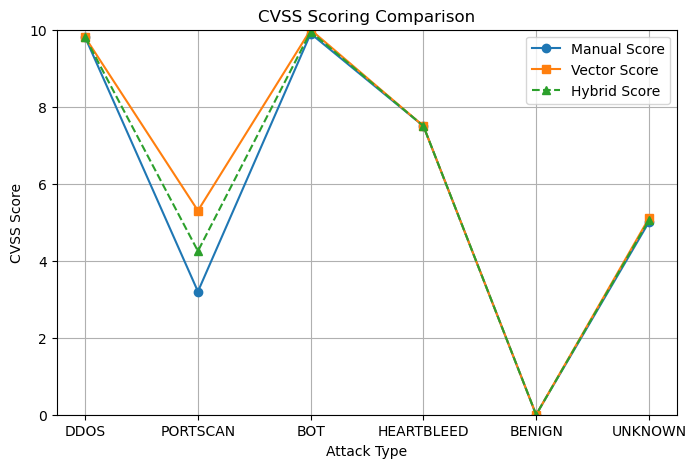

In [173]:
import matplotlib.pyplot as plt

attacks = ["DDOS", "PORTSCAN", "BOT", "HEARTBLEED", "BENIGN", "UNKNOWN"]
manual = [9.8, 3.2, 9.9, 7.5, 0.0, 5.0]
vector = [9.8, 5.3, 10.0, 7.5, 0.0, 5.1]
hybrid = [9.8, 4.25, 9.95, 7.5, 0.0, 5.05]

plt.figure(figsize=(8,5))
plt.plot(attacks, manual, marker='o', label='Manual Score')
plt.plot(attacks, vector, marker='s', label='Vector Score')
plt.plot(attacks, hybrid, marker='^', label='Hybrid Score', linestyle='--')
plt.title("CVSS Scoring Comparison")
plt.xlabel("Attack Type")
plt.ylabel("CVSS Score")
plt.ylim(0, 10)
plt.legend()
plt.grid(True)
plt.show()
